In [1]:
from typing import Dict, List, Any
import numpy as np
from numpy.typing import NDArray
import pandas as pd

from model_ranking.results import (
    get_summary_results, 
    per_source_model_results,
    cmb_consistency_score_weighted_average,
)
from model_ranking.plots import plot_alpha_sweep_specific_norm
from model_ranking.correlation import (
    calculate_correlation_statistics
)

INFO: P [MainThread] 2025-08-01 13:54:29,728 plantseg - Logger configured at initialisation. PlantSeg logger name: plantseg


In [2]:
per_source_consis_result_type =  Dict[str, Dict[str, Dict[str, NDArray[Any]]]]
per_source_performance_result_type = Dict[str, Dict[str, float]]
per_target_consis_result_type = Dict[str, per_source_consis_result_type]
per_target_performance_result_type = Dict[str, per_source_performance_result_type]

In [3]:
NA_UNet_source_models = {
    "EPFL": "E_model_NA2",
    "Hmito": "Hm_model_NA2",
    "Rmito": "Rm_model_NA2",
    "VNC": "V_model_NA2",
}
Res_source_models = {
    "EPFL": "E_model_Res1",
    "Hmito": "Hm_model_Res1",
    "Rmito": "Rm_model_Res1",
    "VNC": "V_model_Res1",
}
Unet_source_models={
    "EPFL": "E_model4",
    "Hmito": "Hm_model3",
    "Rmito": "Rm_model3",
    "VNC": "V_model1",
}
consis_keys={
    "EPFL": "EI_consis",
    "Hmito": "EI_consis",
    "Rmito": "EI_consis",
    "VNC": "EI_consis",
}
consis_keys_bckg = {
    "EPFL": "EI_consis_bckg",
    "Hmito": "EI_consis_bckg",
    "Rmito": "EI_consis_bckg",
    "VNC": "EI_consis_bckg",
}
result_folders={
    "EPFL": "FP_full",
    "Hmito": "FP_full",
    "Rmito": "FP_full",
    "VNC": "FP_full",
}

per_target_norms: Dict[str, List[None]] = {
    "EPFL": [None],
    "Hmito": [None],
    "Rmito": [None],
    "VNC": [None],
}

perf_key = "hard_f1"
approach="feature_perturbation_consistency"
base_result_path = "/scratch/talks/consistency_results/patch_segmentation/mitochondria"

In [4]:
summary_results_postfix = "_full"
selected_augmentations = {
    "none": [""],
    "DO": ["a0001", "a0005", "a001", "a002", "a003", "a004", "a005", "a01"],
}
targets = ["EPFL", "Hmito", "Rmito", "VNC"]
source_model_types = [NA_UNet_source_models, Res_source_models, Unet_source_models]

In [5]:
per_target_forg_consistency: per_target_consis_result_type= {}
per_target_forg_performance: per_target_performance_result_type = {}
for i, target in enumerate(targets):
    if target == "VNC":
        sources = ["EPFL", "Hmito", "Rmito"]
    else:
        sources = ["EPFL", "Hmito", "Rmito", "VNC"]
    per_source_forg_consistency = {}
    per_source_forg_performance = {}

    for model_type in source_model_types:

        consis_str, _, NA_perf = get_summary_results(
            source_data=sources,
            target_data=[target],
            source_models = model_type,
            selected_augmentations=selected_augmentations,
            selected_norms=per_target_norms,
            consis_keys=consis_keys,
            perf_key=perf_key,
            per_target_norms=True,
            result_folders=result_folders,
            approach=approach,
            consis_postfix="median",
            perf_postfix="median",
            summary_results_postfix=summary_results_postfix,
            base_seg_dir=base_result_path,
        )
        per_source_forg_consistency.update(
            per_source_model_results(
                consis_str, 
                source_models=model_type, 
            ))
        per_source_forg_performance.update(
            per_source_model_results(
                NA_perf, 
                source_models=model_type,
            ))
    
    per_target_forg_consistency[target] = per_source_forg_consistency
    per_target_forg_performance[target] = per_source_forg_performance


Source: EPFL


100%|██████████| 1/1 [00:00<00:00, 12.09it/s]


Source: Hmito


100%|██████████| 1/1 [00:00<00:00, 13.98it/s]


Source: Rmito


...

100%|██████████| 1/1 [00:00<00:00, 22.79it/s]


Source: Hmito


100%|██████████| 1/1 [00:00<00:00, 13.70it/s]


Source: Rmito


100%|██████████| 1/1 [00:00<00:00, 15.79it/s]


In [6]:
per_target_bckg_consistency: Dict[str, Dict[str, Dict[str, Dict[str, NDArray[Any]]]]] = {}
per_target_bckg_performance: Dict[str, Dict[str, Dict[str, NDArray[Any]]]] = {}

for i, target in enumerate(targets):
    if target == "VNC":
        sources = ["EPFL", "Hmito", "Rmito"]
    else:
        sources = ["EPFL", "Hmito", "Rmito", "VNC"]
    per_source_bckg_consistency = {}
    per_source_bckg_performance = {}

    for model_type in source_model_types:

        consis_str, _, NA_perf = get_summary_results(
            source_data=sources,
            target_data=[target],
            source_models = model_type,
            selected_augmentations=selected_augmentations,
            selected_norms=per_target_norms,
            consis_keys=consis_keys_bckg,
            perf_key=perf_key,
            per_target_norms=True,
            result_folders=result_folders,
            approach=approach,
            consis_postfix="median",
            perf_postfix="median",
            summary_results_postfix=summary_results_postfix,
            base_seg_dir=base_result_path,
        )
        per_source_bckg_consistency.update(
            per_source_model_results(
                consis_str, 
                source_models=model_type, 
            ))
        per_source_bckg_performance.update(
            per_source_model_results(
                NA_perf, 
                source_models=model_type,
            ))
        
    
    per_target_bckg_consistency[target] = per_source_bckg_consistency
    per_target_bckg_performance[target] = per_source_bckg_performance

    

Source: EPFL


100%|██████████| 1/1 [00:00<00:00, 26.76it/s]


Source: Hmito


100%|██████████| 1/1 [00:00<00:00, 23.92it/s]


Source: Rmito


...

100%|██████████| 1/1 [00:00<00:00, 28.16it/s]


Source: Hmito


100%|██████████| 1/1 [00:00<00:00, 18.31it/s]


Source: Rmito


100%|██████████| 1/1 [00:00<00:00, 19.80it/s]


In [7]:
per_target_cmb_consistency = cmb_consistency_score_weighted_average(
    per_target_forg_consistency,
    per_target_bckg_consistency,
    w_fg=0.5,
    w_bg=0.5,
)

In [8]:
per_target_KT = np.zeros((len(targets), len(selected_augmentations["DO"]), 2))
per_target_SP = np.zeros((len(targets), len(selected_augmentations["DO"]), 2))
per_target_PE = np.zeros((len(targets), len(selected_augmentations["DO"]), 2))
for i, target in enumerate(targets):
    (per_target_KT[i], 
        per_target_SP[i], 
        per_target_PE[i]
    ) = calculate_correlation_statistics(
            per_target_cmb_consistency[target],
            per_target_forg_performance[target],
            selected_augmentations,
            perturbation_key="DO",
        )

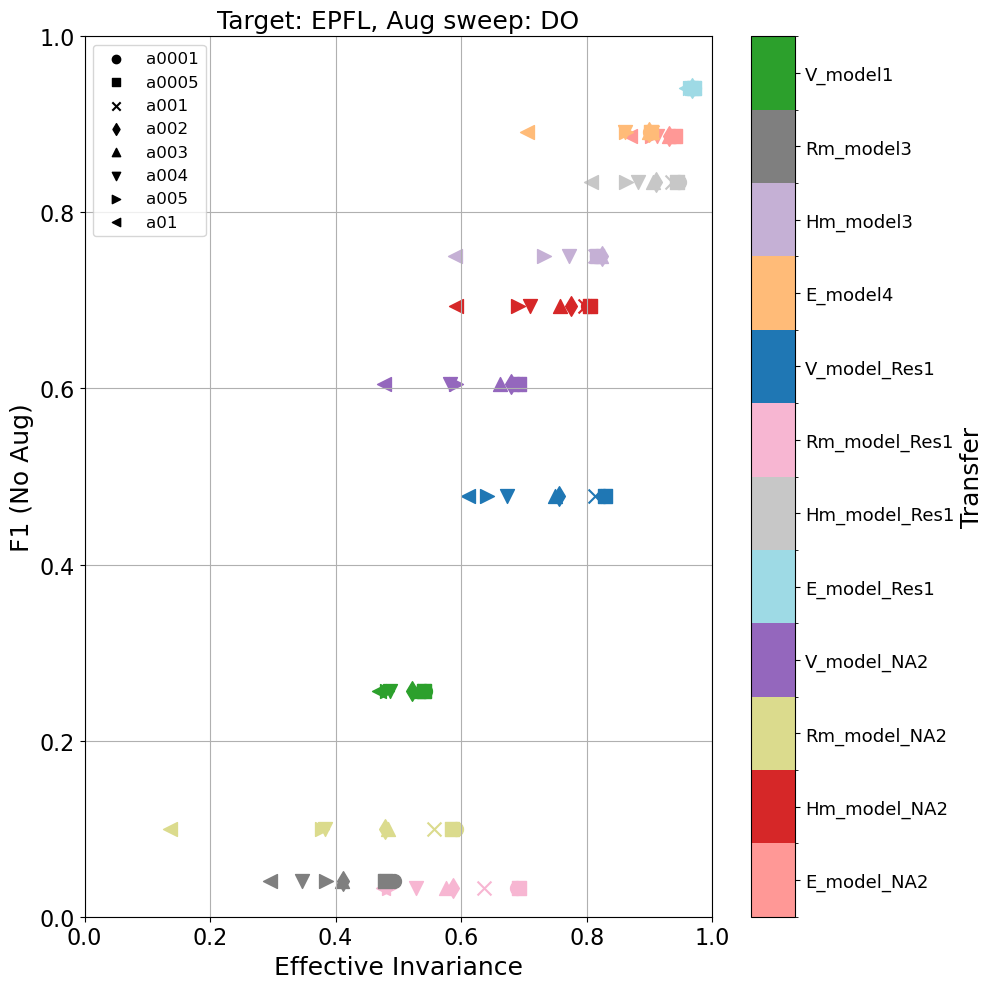

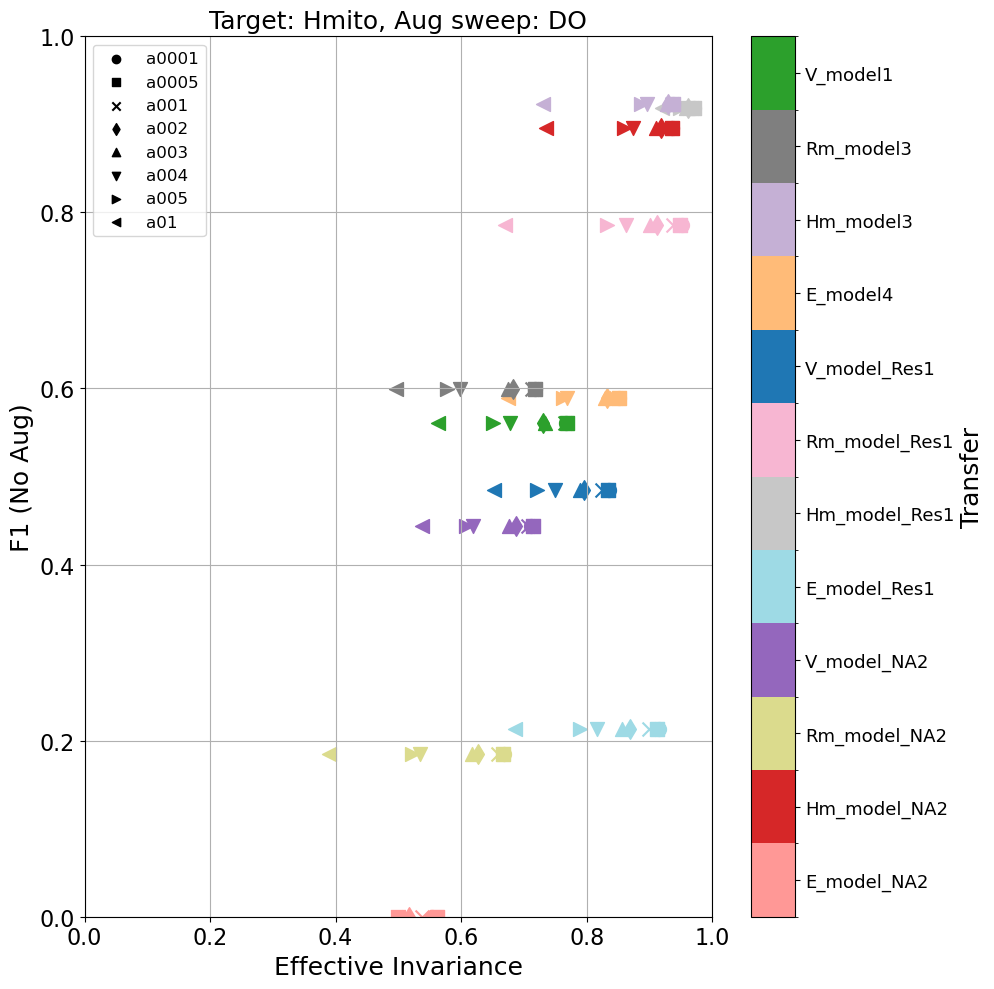

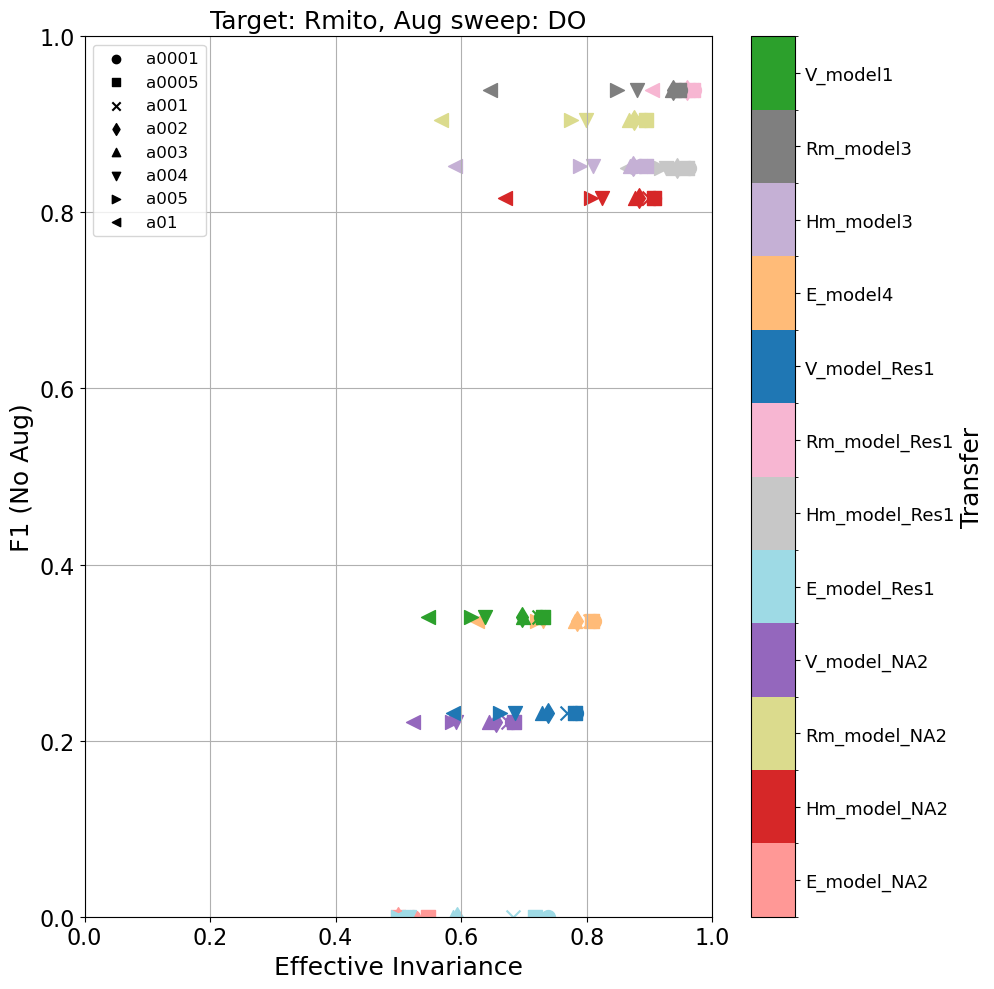

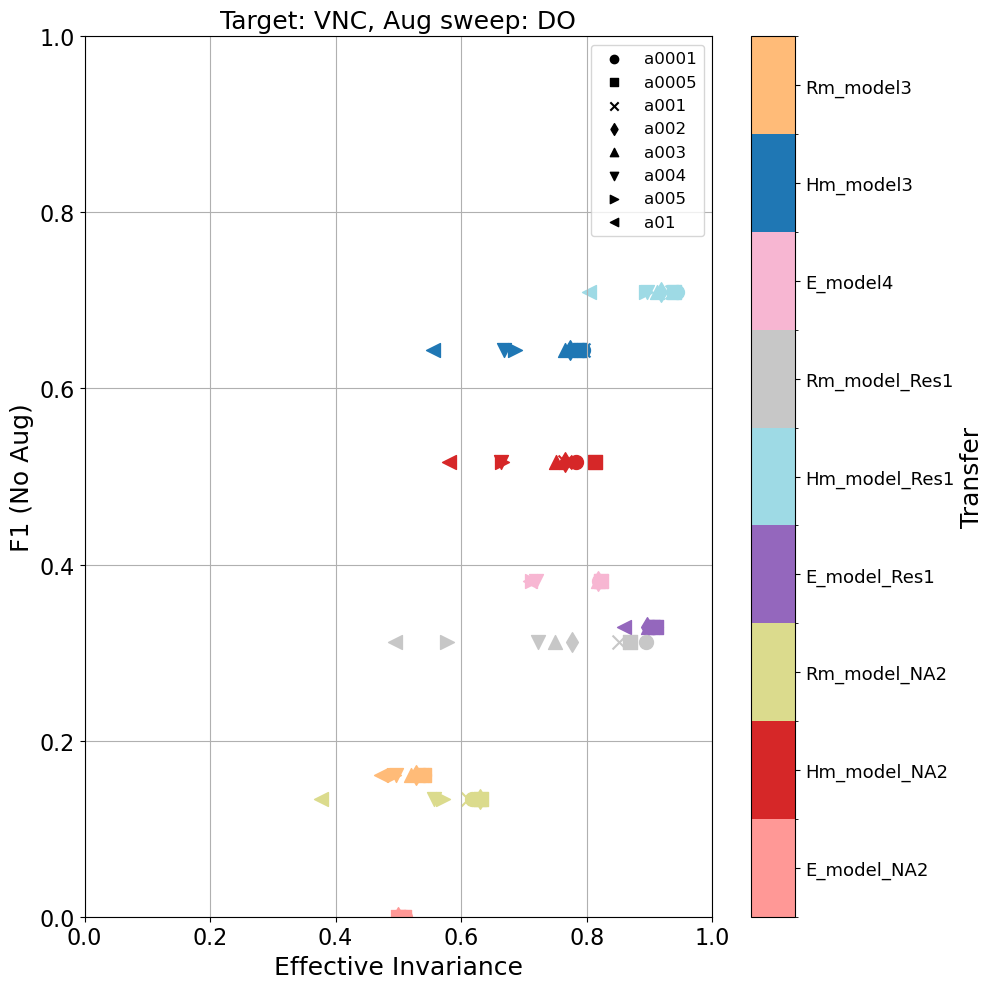

In [9]:
for target in targets:
    plot_alpha_sweep_specific_norm(
        per_target_cmb_consistency[target],
        per_target_forg_performance[target],
        augs=["DO"],
        select_alphas=selected_augmentations,
        select_norms=per_target_norms,
        consistency_metric_name="Effective Invariance",
        invert_consis_metric= False,
        invert_perf_metric=False,
        pos_correlation_line=False,
        per_transfer_norms=False,
        single_target=target,
        xlim=(0, 1),
        n_rows=1,
        n_cols = 1,
    )
(
    pearson_scores, 
    spearman_scores, 
    kendall_tau_scores
) = calculate_correlation_statistics(
        per_target_cmb_consistency[target],
        per_target_forg_performance[target],
        selected_augmentations,
        perturbation_key="DO",
    )
